In [56]:
import pandas as pd
import torch
from torch import nn as nn
from torch import optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from torch.utils.data import Dataset, DataLoader
import numpy as np
import gc
import optuna
import math
import matplotlib.pyplot as plt

In [111]:
%config InteractiveShell.ast_node_interactivity = 'all'

In [109]:
%config InteractiveShell.ast_node_interactivity = 'last_expr'

In [89]:
data = pd.DataFrame(pd.read_csv("000420.XSHE.csv", parse_dates=["datetime"]).set_index("datetime"))
data = data[["close"]].resample("D").last().dropna()
data.describe()

,close
count,4373.000000
mean,2.719561
std,1.201007
min,0.790000
25%,1.770000
50%,2.560000
75%,3.470000
max,6.780000


In [ ]:
print(data.head(30))

Text(0.5, 1.0, 'close-over-time')

Text(0.5, 0, 'Time')

Text(0, 0.5, 'Stock Price')

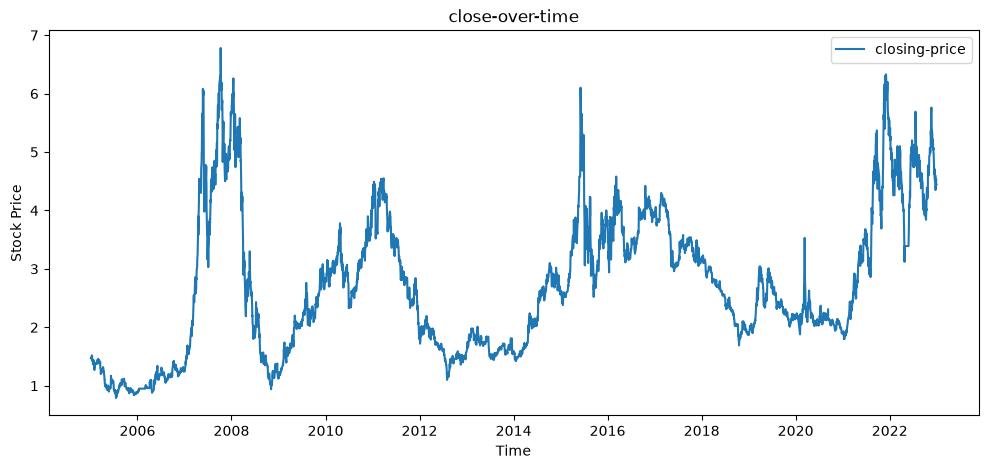

In [54]:
fig=plt.figure()
fig.set_figwidth(12)
fig.set_figheight(5)
plt.plot(data, label='closing-price')
plt.title('close-over-time')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [90]:
data["diff"] = data["close"].diff()
data.dropna(subset=["diff"], inplace=True)

sc = MinMaxScaler()
data["data_diff_sc"] = sc.fit_transform(data[["diff"]])

data.drop(columns=["diff"], inplace=True)
# finalnie kolumny datetime/close/diffsc

n = len(data)
look_back = 60
batch_size = 32
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data.iloc[:train_end]
val_data = data.iloc[train_end - look_back : val_end]
test_data = data.iloc[val_end - look_back :]

class TimeSeriesDataset(Dataset):
    def __init__(self, df, feature_col='data_diff_sc', look_back=look_back):
        arr = df[feature_col].to_numpy(dtype=np.float32)
        self.data = torch.from_numpy(arr).unsqueeze(1)
        self.look_back = look_back

    def __len__(self):
        return len(self.data) - self.look_back

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.look_back]

        y = self.data[idx + self.look_back]

        return x, y


train_dataset = TimeSeriesDataset(train_data)
val_dataset = TimeSeriesDataset(val_data)
test_dataset = TimeSeriesDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [79]:
class Net(nn.Module):
    def __init__(self, num_layers, hidden_size, input_size=1, output_size=1, dropout=0.2):
        super(Net, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, output_size) #last layer

    def forward(self, x): #forward method
       out, _ = self.gru(x)
       last= out[:, -1, :]
       return self.fc(last)

In [80]:
def objective(trial):
    layer_number = trial.suggest_int("layer_number", 1, 3)
    hidden_size = trial.suggest_int('hidden_size', 16, 256, step = 16)
    learning_rate = trial.suggest_float('lr', 1e-4, 1e-1, log=True)

    model = Net(layer_number, hidden_size, input_size=1, output_size=1, dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    for epoch in range(5): #5 passes through training data
        model.train() #training mode
        for batch_idx, (x, y) in enumerate(train_loader):
            optimizer.zero_grad() #reset gradient to zero between passes
            output = model(x) #forward pass
            loss = criterion(output, y)
            loss.backward() #backward pass
            optimizer.step() #weight update

        model.eval() #evaluation mode
        total_loss = 0.0 #loss tracking
        with torch.no_grad(): #memory saver, no gradient tracking engine
            for x, y in val_loader:
                pred = model(x)   #forward pass
                loss = criterion(pred, y) #loss per batch
                total_loss += loss.item() #add loss from current batch

        val_av = total_loss / len(val_loader)

        trial.report(val_av, epoch)
        if trial.should_prune(): #time saver
            del model
            gc.collect()
            raise optuna.exceptions.TrialPruned()

    del model
    gc.collect() #laptop saver

    return val_av #loss for the last epoch

In [82]:
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2, interval_steps=1)) #two trials to prove itself for tests 6 and beyond
study.optimize(objective, n_trials=40)
best_params = study.best_params
best_value = study.best_value

study_num_layers = best_params["layer_number"]
study_lr = best_params["lr"]
study_hidden_size = best_params["hidden_size"]

print(best_params)
print(best_value)

[I 2026-07-30 15:08:06,634] A new study created in memory with name: no-name-8b1ec794-a49e-49a5-9f56-05f74ec53af0
[I 2026-07-30 15:09:22,217] Trial 0 finished with value: 0.0028909697568797995 and parameters: {'layer_number': 1, 'hidden_size': 80, 'lr': 0.002337193824227812}. Best is trial 0 with value: 0.0028909697568797995.
[I 2026-07-30 15:16:57,114] Trial 1 finished with value: 0.002964956167575327 and parameters: {'layer_number': 3, 'hidden_size': 256, 'lr': 0.012894845233201911}. Best is trial 0 with value: 0.0028909697568797995.
[I 2026-07-30 15:19:07,994] Trial 2 finished with value: 0.003097720738012521 and parameters: {'layer_number': 1, 'hidden_size': 192, 'lr': 0.008236920836418733}. Best is trial 0 with value: 0.0028909697568797995.
[I 2026-07-30 15:21:49,379] Trial 3 finished with value: 0.0028940358038415156 and parameters: {'layer_number': 1, 'hidden_size': 176, 'lr': 0.0005498155463647151}. Best is trial 0 with value: 0.0028909697568797995.
[I 2026-07-30 15:23:06,556] 

{'layer_number': 1, 'hidden_size': 256, 'lr': 0.0072038388550058185}
0.002851333288985881


In [ ]:
modelFinal = Net(
    num_layers=study_num_layers,
    hidden_size=study_hidden_size,
)

optimizer = optim.Adam(modelFinal.parameters(), lr=study_lr)
criterion = nn.MSELoss()
best_val_loss = float('inf')

for epoch in range(10): #it ran a while already i just had to pause it (best 0.002702)
    train_loss = 0.0 #loss reset
    modelFinal.train()
    for data, target in train_loader:
        optimizer.zero_grad(set_to_none=True)
        output = modelFinal(data) #forward pass
        loss = criterion(output, target) #loss calculation
        loss.backward() #backward pass
        torch.nn.utils.clip_grad_norm_(modelFinal.parameters(), max_norm=0.2) #lobotomy prevention clause (gradient clipping)
        optimizer.step() #weight update
        train_loss += loss.item()*data.size(0) #MSE calculates batch average
    t_loss_avg = train_loss / len(train_dataset)

    modelFinal.eval()
    val_loss = 0.0

    with torch.inference_mode():
        for data, target in val_loader:
            output = modelFinal(data)
            loss = criterion(output, target)
            val_loss += loss.item() * data.size(0)

    val_loss_avg = val_loss / len(val_dataset)

    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        torch.save(modelFinal.state_dict(), 'best_weights.pth') #checkpoint
        print(f'[{epoch+1}/100], Train: {t_loss_avg:.6f} | Val: {val_loss_avg:.6f} --new best')
    else:
        print(f'[{epoch+1}/100], Train: {t_loss_avg:.6f} | Val: {val_loss_avg:.6f}')

In [100]:
modelFinal.load_state_dict(torch.load("best_weights.pth", weights_only=True))

modelFinal.eval()

with torch.inference_mode():
  predict_diff = sc.inverse_transform(
      torch.cat([modelFinal(x) for x, _ in test_loader]).numpy()
  ).flatten()

test_close = test_data["close"].to_numpy()

actual = test_close[look_back:]
predicted_close = test_close[look_back - 1 : -1] + predict_diff

Text(0.5, 1.0, 'Closing Price - Actual vs Predicted')

Text(0.5, 0, 'Time')

Text(0, 0.5, 'Stock Price')

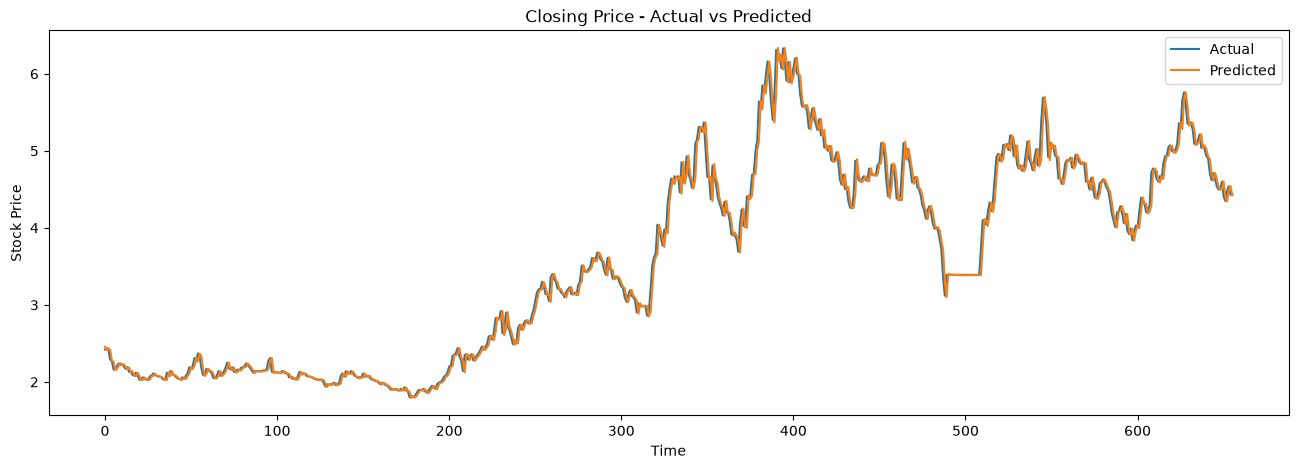

In [112]:
fig=plt.figure()
fig.set_figwidth(16)
fig.set_figheight(5)
plt.plot(actual, label='Actual')
plt.plot(predicted_close, label='Predicted')
plt.title('Closing Price')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [107]:
actual_diff = np.diff(test_close)[look_back - 1 :]
hit_rate = np.mean(np.sign(actual_diff) == np.sign(predict_diff)) * 100
mae = np.mean(np.abs(actual - predicted_close))
print(f'hit rate: {hit_rate}')
print(f'mean absolute error: {mae}')

hit rate: 46.34146341463415
mean absolute error: 0.08496489872665552


**so essentially it's kinda ass because it predicts day to day change worse than random it just took previous-day data to minimize raw error lol** \
changing it to evaluating binary up/down changes would maybe work better